In [1]:
import os # Needed for the path funtions like join, basename ..
import sys # Needed to add the src folder to the hidden list of folder locations that Python searches through whenever an import statement is typed. If a folder isn't in this list, Python cannot see the code files inside it.
import glob #Needed for fetching files from directories
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import IPython.display as ipd

# Connect to the src folder
sys.path.append(os.path.abspath(".."))
from src.data_loader import extract_and_serialize_features

# Define global paths for the data source where the audio files are kept and where the .npy files are to be kept
DATA_SOURCE = os.path.join("..", "data", "raw")
DATA_DESTINATION = os.path.join("..", "data")

Visualizing Sample: 03-01-01-01-01-01-01.wav
--- DIGITAL AUDIO MATH ---
1. Total Array Items (Samples): 52,853
2. Sampling Rate (Snapshots per second): 16,000 Hz
3. Deduced Duration: 52,853 / 16,000 = 3.30 seconds



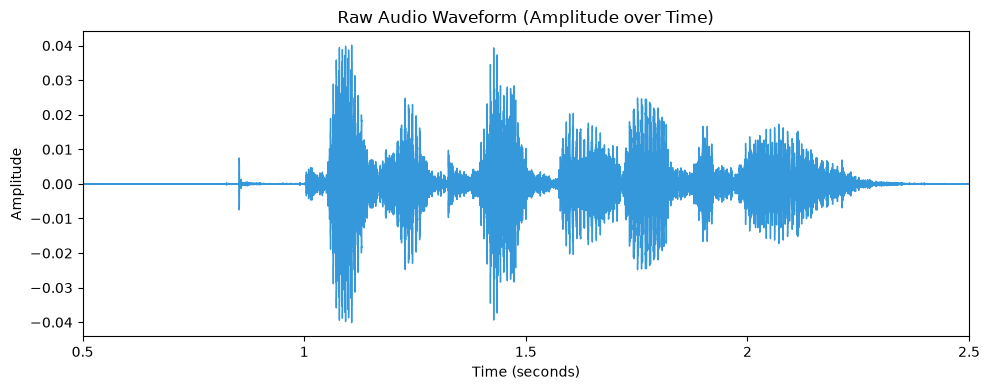

In [9]:
# Grabbing the very first audio file found in the raw directory to perform an EDA (Exploratory Data Analysis)
sample_files = glob.glob(os.path.join(DATA_SOURCE, "**", "*.wav"), recursive=True) #Contains all the filepath of all audio files in the raw directory

if sample_files:
    eda_file_path = sample_files[0] # Grabbing just the first file path out of the list of all file path containing the .wav audio files
    print(f"Visualizing Sample: {os.path.basename(eda_file_path)}") #Printing the filename of the very first file path. The output is a string of the filename
    
    # Load raw audio (using unique variable names to avoid conflicts with custom libraries created for the purpose of this project)
    # Loading the audio file into a Numpy array using librosa.load from a wav file using a sampling rate of 16000Hz 
    # The output of librosa.load is a tuple holding the array and the sampling rate used(22050 Hz is the default used if not specified), the input is the filepath to the audio file
    # We are using the default of librosa.load that forces stereo audio files into mono. The shape of the resulting array is a flat, 1D array where the length equals sample_rate × total duration (seconds). 
    eda_audio_array, eda_sr = librosa.load(eda_file_path, sr=16000)

    # Summary of the Data loaded into the Array using librosa.load 
    total_samples = len(eda_audio_array) # To know the number the number of data points in the array
    duration_seconds = total_samples / eda_sr # Using the sample rate and number of data points to determine the seconds of audio loaded. (Sampling Rate * Seconds = Total Array Item)
    
    # The Audio Math Deduction 
    print("--- DIGITAL AUDIO MATH ---")
    print(f"1. Total Array Items (Samples): {total_samples:,}")
    print(f"2. Sampling Rate (Snapshots per second): {eda_sr:,} Hz")
    print(f"3. Deduced Duration: {total_samples:,} / {eda_sr:,} = {duration_seconds:.2f} seconds\n")
    
    # Plot the Waveform
    plt.figure(figsize=(10, 4))
    librosa.display.waveshow(eda_audio_array, sr=eda_sr, color="#3498db")
    plt.title("Raw Audio Waveform (Amplitude over Time)")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.xlim(0.5,2.5)
    plt.tight_layout()
    plt.savefig("waveform_plot.png", dpi=300, bbox_inches="tight")
    plt.show()
    
    # Display the interactive audio player
    display(ipd.Audio(eda_audio_array, rate=eda_sr))
else:
    print("Error: No audio files found. Check your DATA_SOURCE path.")

In [10]:
# Run our custom tool to extract MFCCs and save the data
extract_and_serialize_features(DATA_SOURCE, DATA_DESTINATION) #Running the custom function defined previously and saved

Discovered 1440 files. Starting extraction...
Processed 100/1440 files...
Processed 200/1440 files...
Processed 300/1440 files...
Processed 400/1440 files...
Processed 500/1440 files...
Processed 600/1440 files...
Processed 700/1440 files...
Processed 800/1440 files...
Processed 900/1440 files...
Processed 1000/1440 files...
Processed 1100/1440 files...
Processed 1200/1440 files...
Processed 1300/1440 files...
Processed 1400/1440 files...

--- EXTRACTION COMPLETE ---
X Shape: (1440, 20, 125)
y Shape: (1440,)
Saved to ..\data


In [11]:
# Load the saved data to prove it worked
X = np.load(os.path.join(DATA_DESTINATION, "X_features.npy"))
y = np.load(os.path.join(DATA_DESTINATION, "y_labels.npy"))

print(f"Verified Final X Shape: {X.shape}")
print(f"Verified Final y Shape: {y.shape}")

Verified Final X Shape: (1440, 20, 125)
Verified Final y Shape: (1440,)


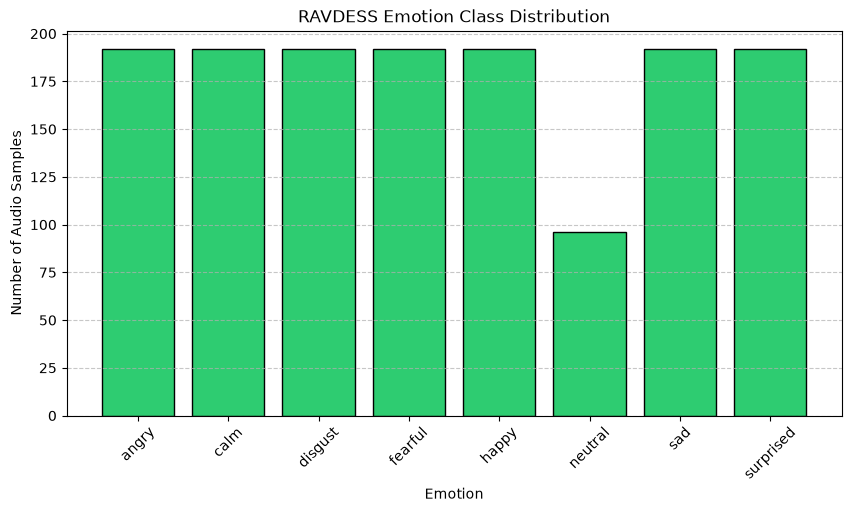

In [12]:
# ==========================================
# CELL 5: EDA - Class Distribution
# ==========================================
# Count the occurrences of each emotion
classes, counts = np.unique(y, return_counts=True)

plt.figure(figsize=(10, 5))
plt.bar(classes, counts, color='#2ecc71', edgecolor='black')
plt.title("RAVDESS Emotion Class Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Audio Samples")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

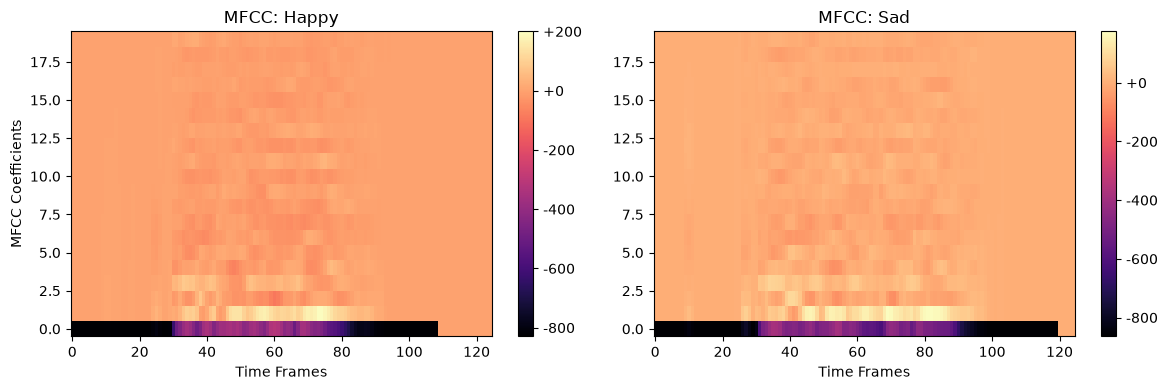

In [13]:
# ==========================================
# CELL 6: EDA - Comparative MFCCs (Happy vs. Sad)
# ==========================================
# Find the first index of a 'happy' file and a 'sad' file
happy_idx = np.where(y == 'happy')[0][0]
sad_idx = np.where(y == 'sad')[0][0]

plt.figure(figsize=(12, 4))

# Plot Happy
plt.subplot(1, 2, 1)
plt.imshow(X[happy_idx], aspect='auto', origin='lower', cmap='magma')
plt.title("MFCC: Happy")
plt.ylabel('MFCC Coefficients')
plt.xlabel('Time Frames')
plt.colorbar(format='%+2.0f')

# Plot Sad
plt.subplot(1, 2, 2)
plt.imshow(X[sad_idx], aspect='auto', origin='lower', cmap='magma')
plt.title("MFCC: Sad")
plt.xlabel('Time Frames')
plt.colorbar(format='%+2.0f')

plt.tight_layout()
plt.show()